---
# Import Library

---

In [1]:
# Processing and Displying Data in DataFrame form.
import pandas as pd

# Calculate Data.
import numpy as np

 
import seaborn as sns
import matplotlib.pyplot as plt

# Colleration Check each column.
import phik

# for handling missing value
from sklearn.impute import SimpleImputer

# Spliting Data into Train and Test
from sklearn.model_selection import train_test_split

# handling Outlier.
from feature_engine.outliers import Winsorizer

# Scaling Data. (Numeric - Skew), Encode Data. (Categorical - Nominal), Funtiontransformer (storing funtion to included in pipeline)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer

# to keep feature as is as train feature
from sklearn.compose import ColumnTransformer

# for pipeline
from sklearn.pipeline import make_pipeline

# Machine Learning Model.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# hyperparameter tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_val_predict

# Calculate, compare, visualize Predict Score.
from sklearn.metrics import precision_score, f1_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, average_precision_score

# Model Saving.
import pickle

import shap

# Ignoring Warning from Python.
import warnings
warnings.filterwarnings("ignore")

---
# Data Loading

---

In [2]:
# Using file from cleaned Folder outside .ipynb path file
Data = pd.read_csv('../data/cleaned/order_agg_modeling_v0_1.csv', index_col=0)
Backup_data = Data.copy()

In [3]:
# to Shown all column.
pd.options.display.max_columns = None

# check summary of data
Data.info()

# top 5 Data Sample.
Data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 98832 entries, 0 to 99440
Data columns (total 20 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       98832 non-null  object 
 1   customer_id                    98832 non-null  object 
 2   order_status                   98832 non-null  object 
 3   order_purchase_timestamp       98832 non-null  object 
 4   order_approved_at              98672 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  98832 non-null  object 
 8   total_items                    98660 non-null  float64
 9   total_order_value              98660 non-null  float64
 10  total_freight                  98660 non-null  float64
 11  avg_item_price                 98660 non-null  float64
 12  payment_type                   98831 non-null  obje

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_items,total_order_value,total_freight,avg_item_price,payment_type,total_payment_value,max_installments,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,is_canceled
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,29.99,8.72,29.99,voucher,38.71,1.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,118.70,22.76,118.70,boleto,141.46,1.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,159.90,19.22,159.90,credit_card,179.12,3.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1.0,45.00,27.20,45.00,credit_card,72.20,1.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1.0,19.90,8.72,19.90,credit_card,28.62,1.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,0


By above output, all of the column data type in the dataset behave as they shold be. However, note that the dataset still contains some missing values. We will handle these missing values later before modeling process further.

---
# Feature Engineering

---

---
## Duplicated Check

---

In [4]:
print(f"Duplicated Data  : {Data.duplicated().sum()}")
print(f"Total Data : {Data.shape[0]}")

Duplicated Data  : 0
Total Data : 98832


Based on the duplicate check, no duplicated records were found in the dataset.

---

---
## Missing value Check

---

In [5]:
Data.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1174
order_delivered_customer_date    2356
order_estimated_delivery_date       0
total_items                       172
total_order_value                 172
total_freight                     172
avg_item_price                    172
payment_type                        1
total_payment_value                 1
max_installments                    1
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
is_canceled                         0
dtype: int64

Based on the Missing Value check, there are some columns that need to be handled.

---

---
## Missing Value Handling

---
In this section, only handle some missing values that not including impute process with mean value for numerical and modus for categorical variables. Moreover, missing value handling that includes impute process with mean value or modus value (that needs to be based on train set only, to prevent data leakage) will be done later after train-test split.

In [6]:
Data_Processed = Data.drop(columns=['order_approved_at'
                        ,'order_delivered_carrier_date'
                        ,'order_delivered_customer_date'
                        ,'order_estimated_delivery_date']
                ,axis=1 )

Note that we concerned for the cancellation rate and want to predict whether the order will be cancelled or not. In the future, we will notify (by system) the warning of such order will be cancelled prior the order approved by the system. Hence, the objective of the model is to predict the cancellation rate **before** the transaction is approved, which impact to the approval date column and all subsequent activity (after transaction is approved) date columns will be dropped.

---

In [7]:
Missing_Data = Data_Processed[Data_Processed['payment_type'].isnull()].index
Data_Processed.loc[Missing_Data]

,order_id,customer_id,order_status,order_purchase_timestamp,total_items,total_order_value,total_freight,avg_item_price,payment_type,total_payment_value,max_installments,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,is_canceled
30710,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,3.0,134.97,8.49,44.99,NaN,NaN,NaN,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,0


In [8]:
Data_Processed = Data_Processed.dropna(subset=['payment_type','max_installments','total_payment_value'],axis=0)

Note that, all columns of payment data that is `payment_type`, `max_installments`, and `total_payment_value` all simultaneously missing for the same `order_id`, that is for the `order_id` **bfbd0f9bdef84302105ad712db648a6c**. Also, by checking other columns values, it appears independent of other columns, this is **MCAR** type of missing.

Since payment attributes represent essential transaction signals that may influence customer behavior of cancellation patterns, a record with completely absent payment information provides no basis of these payment data informations. Given that only a single record that affected and no meaningful imputation strategy exists for a fully missing transactional record, this row will be removed to preserve dataset integrity.

---

In [9]:
Missing_Data_2 = Data_Processed[Data_Processed['total_items'].isnull()].index
Data_Processed.loc[Missing_Data_2].head()

,order_id,customer_id,order_status,order_purchase_timestamp,total_items,total_order_value,total_freight,avg_item_price,payment_type,total_payment_value,max_installments,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,is_canceled
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaN,NaN,not_defined,0.00,1.0,4fa4365000c7090fcb8cad5713c6d3db,1151,sao paulo,SP,1
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaN,NaN,voucher,191.46,1.0,08642cd329066fe11ec63293f714f2f8,33030,santa luzia,MG,1
1868,df8282afe61008dc26c6c31011474d02,aa797b187b5466bc6925aaaa4bb3bed1,canceled,2017-03-04 12:14:30,NaN,NaN,NaN,NaN,boleto,139.96,1.0,c219f4ac1bc7f1aea33e6ab8885831e8,68742,castanhal,PA,1
2029,8d4c637f1accf7a88a4555f02741e606,b1dd715db389a2077f43174e7a675d07,canceled,2018-08-29 16:27:49,NaN,NaN,NaN,NaN,voucher,66.44,1.0,a8dd81392e5eee5d979c629a76abec2a,13059,campinas,SP,1
2161,7a9d4c7f9b068337875b95465330f2fc,7f71ae48074c0cfec9195f88fcbfac55,canceled,2017-05-01 16:12:39,NaN,NaN,NaN,NaN,credit_card,72.90,2.0,29dc4aeff866d6a940c471a3ea4faef0,5752,sao paulo,SP,1


In [10]:
Data_Processed['total_items'] = Data_Processed['total_items'].fillna(0)
Data_Processed['total_order_value'] = Data_Processed['total_order_value'].fillna(0)
Data_Processed['total_freight'] = Data_Processed['total_freight'].fillna(0)
Data_Processed['avg_item_price'] = Data_Processed['avg_item_price'].fillna(0)

TODO need to revise because need to impute 0 to all affected row   
Missing values in `total_items` are imputed with `1` under the assumption that **each order must contain at least one item**. Since **an order cannot exist without any item**.

For `total_order_value` and `avg_item_price` are imputed using `total_payment_value`, with `total_items` are inputed as 1, the `total_order_value` and `avg_item_price` are equivalent to the total amount paid.

For `total_freight` are imputed with `0` as default because min value for `total_freight` is `0` that indicate as **free shipping**.

---

In [11]:
Data_Processed.isnull().sum()

order_id                    0
customer_id                 0
order_status                0
order_purchase_timestamp    0
total_items                 0
total_order_value           0
total_freight               0
avg_item_price              0
payment_type                0
total_payment_value         0
max_installments            0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
is_canceled                 0
dtype: int64

Note that after all above process, no missing value records were found in the dataset. Therefore, there will be no process of missing value handling that requires impute with mean (for numerical) and modus (for categorical) value after train-test split. We will move forward to the next step, split the column X (features) & y (target) from the dataset.

---

---
## Split column X & y

---

In [12]:
# Excluding column that like primary key, candidate primary key and looks like Target column
X = Data_Processed.drop(columns=['customer_id','order_id','customer_unique_id','order_status','is_canceled'],axis=1)

# using is_canceled column as predict target 
y = Data_Processed.is_canceled

In [13]:
X.head()

,order_purchase_timestamp,total_items,total_order_value,total_freight,avg_item_price,payment_type,total_payment_value,max_installments,customer_zip_code_prefix,customer_city,customer_state
0,2017-10-02 10:56:33,1.0,29.99,8.72,29.99,voucher,38.71,1.0,3149,sao paulo,SP
1,2018-07-24 20:41:37,1.0,118.70,22.76,118.70,boleto,141.46,1.0,47813,barreiras,BA
2,2018-08-08 08:38:49,1.0,159.90,19.22,159.90,credit_card,179.12,3.0,75265,vianopolis,GO
3,2017-11-18 19:28:06,1.0,45.00,27.20,45.00,credit_card,72.20,1.0,59296,sao goncalo do amarante,RN
4,2018-02-13 21:18:39,1.0,19.90,8.72,19.90,credit_card,28.62,1.0,9195,santo andre,SP


In [14]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98831 entries, 0 to 99440
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_purchase_timestamp  98831 non-null  object 
 1   total_items               98831 non-null  float64
 2   total_order_value         98831 non-null  float64
 3   total_freight             98831 non-null  float64
 4   avg_item_price            98831 non-null  float64
 5   payment_type              98831 non-null  object 
 6   total_payment_value       98831 non-null  float64
 7   max_installments          98831 non-null  float64
 8   customer_zip_code_prefix  98831 non-null  int64  
 9   customer_city             98831 non-null  object 
 10  customer_state            98831 non-null  object 
dtypes: float64(6), int64(1), object(4)
memory usage: 11.1+ MB


By above process we have split the dataset into `X` (features) and `y` (target).

---
## Cardinality Check

---

In [15]:
category = ['payment_type','max_installments','customer_zip_code_prefix','customer_city','customer_state']

for i in X[category]:
    print(f'Number of unique value of column `{i}` : {X[i].nunique()}')
    print(f'Unique values of column `{i}` : {X[i].unique()}')
    print('')

Number of unique value of column `payment_type` : 5
Unique values of column `payment_type` : ['voucher' 'boleto' 'credit_card' 'debit_card' 'not_defined']

Number of unique value of column `max_installments` : 24
Unique values of column `max_installments` : [ 1.  3.  6. 10.  4.  2.  8.  9.  7.  5. 13. 12. 15. 14. 21. 18. 24. 17.
 11. 20. 23. 16. 22.  0.]

Number of unique value of column `customer_zip_code_prefix` : 14977
Unique values of column `customer_zip_code_prefix` : [ 3149 47813 75265 ... 83870  5127 45920]

Number of unique value of column `customer_city` : 4111
Unique values of column `customer_city` : ['sao paulo' 'barreiras' 'vianopolis' ... 'messias targino'
 'campo do tenente' 'nova vicosa']

Number of unique value of column `customer_state` : 27
Unique values of column `customer_state` : ['SP' 'BA' 'GO' 'RN' 'PR' 'RS' 'RJ' 'MG' 'SC' 'RR' 'PE' 'TO' 'CE' 'DF'
 'SE' 'MT' 'PB' 'PA' 'RO' 'ES' 'AP' 'MS' 'MA' 'PI' 'AL' 'AC' 'AM']



Based on the Cardinality Check result above, `max_installments`, `customer_zip_code_prefix`, `customer_city`, and `customer_state` are categorized as high-cardinality features and will require appropriate handling.

---

---
## Cardinality handling

---
#TODO menurut ku cuma 1 section aja, yang di atas itu Cardinality Handling, yang di sini gausah. Tapi bebas, bahas di discord saja

#### Handling column `max_installments`:

In [16]:
# create binning of `max_installments` column
X['installment_bin'] = pd.cut(
    X['max_installments']
    ,bins=[0, 6, 12, 18, 24] # 5 binning
    ,labels=['very_short','short','medium','long']
    ,include_lowest=True
)

# create value per installment from max installment divide by total payment value
X['installment_value'] = X['max_installments'] / (X['total_payment_value']+1)

# dropped to reduced cardinality and replaced by `installment_bin`
# X = X.drop('max_installments',axis=1)

TODO   
[need finalize] Reasoning :   
The `max_installments` column cardinality is reduced through a binning process to minimize overfitting risk and enhance model stability.

---

#### Handling column `customer_state`:

In [17]:
Top_9_state = X['customer_state'].value_counts().nlargest(9).index

X['customer_state'] = np.where(X['customer_state'].isin(Top_9_state)
                               ,X['customer_state'] # True Result
                               ,'Other') #False Result

X['customer_state'].value_counts()


customer_state
SP       41453
RJ       12784
MG       11560
Other    11453
RS        5442
PR        5005
SC        3619
BA        3360
DF        2128
ES        2027
Name: count, dtype: int64

The `customer_state` column cardinality is reduced by retaining the **top 9 states** and grouping the remaining states into an `“Other”` category to minimize overfitting risk and enhance model stability.

---

In [18]:
X = X.drop(columns=['customer_zip_code_prefix','customer_city'],axis=1)

TODO   
Reasoning :   
The `customer_zip_code_prefix` and `customer_city` information is overlapping with `customer_state`. These columns will be removed to avoid redundancy and high cardinality issues.

---

---
## Feature Creation

---

#TODO perlu tulis reasoning singkat nya

In [19]:
X['order_purchase_timestamp'] = pd.to_datetime(X['order_purchase_timestamp'])
X['days_of_week'] = X['order_purchase_timestamp'].dt.dayofweek
X['is_weekend'] = X['days_of_week'] >= 5
X['is_weekend'] = X['is_weekend'].astype(int)
X['order_hour'] = X['order_purchase_timestamp'].dt.hour
X = X.drop(columns=['order_purchase_timestamp'], axis=1)
X.head()

,total_items,total_order_value,total_freight,avg_item_price,payment_type,total_payment_value,max_installments,customer_state,installment_bin,installment_value,days_of_week,is_weekend,order_hour
0,1.0,29.99,8.72,29.99,voucher,38.71,1.0,SP,very_short,0.025183,0,0,10
1,1.0,118.70,22.76,118.70,boleto,141.46,1.0,BA,very_short,0.007020,1,0,20
2,1.0,159.90,19.22,159.90,credit_card,179.12,3.0,Other,very_short,0.016656,2,0,8
3,1.0,45.00,27.20,45.00,credit_card,72.20,1.0,Other,very_short,0.013661,5,1,19
4,1.0,19.90,8.72,19.90,credit_card,28.62,1.0,SP,very_short,0.033761,1,0,21


In [20]:
X['freight_ratio'] = np.where(
    X['total_payment_value'] > 0
    ,X['total_freight'] / X['total_payment_value']
    ,0
)
X.head()

,total_items,total_order_value,total_freight,avg_item_price,payment_type,total_payment_value,max_installments,customer_state,installment_bin,installment_value,days_of_week,is_weekend,order_hour,freight_ratio
0,1.0,29.99,8.72,29.99,voucher,38.71,1.0,SP,very_short,0.025183,0,0,10,0.225265
1,1.0,118.70,22.76,118.70,boleto,141.46,1.0,BA,very_short,0.007020,1,0,20,0.160894
2,1.0,159.90,19.22,159.90,credit_card,179.12,3.0,Other,very_short,0.016656,2,0,8,0.107302
3,1.0,45.00,27.20,45.00,credit_card,72.20,1.0,Other,very_short,0.013661,5,1,19,0.376731
4,1.0,19.90,8.72,19.90,credit_card,28.62,1.0,SP,very_short,0.033761,1,0,21,0.304682


---
## Spliting categorical and numerical columns

---

In [21]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98831 entries, 0 to 99440
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   total_items          98831 non-null  float64 
 1   total_order_value    98831 non-null  float64 
 2   total_freight        98831 non-null  float64 
 3   avg_item_price       98831 non-null  float64 
 4   payment_type         98831 non-null  object  
 5   total_payment_value  98831 non-null  float64 
 6   max_installments     98831 non-null  float64 
 7   customer_state       98831 non-null  object  
 8   installment_bin      98831 non-null  category
 9   installment_value    98831 non-null  float64 
 10  days_of_week         98831 non-null  int32   
 11  is_weekend           98831 non-null  int32   
 12  order_hour           98831 non-null  int32   
 13  freight_ratio        98831 non-null  float64 
dtypes: category(1), float64(8), int32(3), object(2)
memory usage: 11.5+ MB


In [22]:
cat_col = ['payment_type','customer_state','installment_bin','is_weekend']
num_col = ['total_items','total_order_value','total_freight','freight_ratio'
           ,'total_payment_value','avg_item_price','order_hour','installment_value']

---
## Train-Test Split

---

In [23]:
# memisahkan data menjadi Train & Test dengan persentase 85% Train dan 15% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.15, stratify=y, random_state = 50)

# menampilkan banyaknya data Train
print(f"Train Data Size : {X_train.shape[0]}\n")

# menampilkan banyaknya data Test
print(f"Test Data Size : {X_test.shape[0]}")

Train Data Size : 84006

Test Data Size : 14825


---
## Outliers Handling

---

In [24]:
X_train_log = X_train

X_train_log[num_col].describe()

,total_items,total_order_value,total_freight,freight_ratio,total_payment_value,avg_item_price,order_hour,installment_value
count,84006.000000,84006.000000,84006.000000,84006.000000,84006.000000,84006.000000,84006.000000,84006.000000
mean,1.138966,137.284193,22.770919,0.208461,160.471442,125.506967,14.777873,0.026609
std,0.538564,210.536660,21.682108,0.125904,220.882473,189.589088,5.338047,0.023552
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,45.900000,13.820000,0.116258,62.010000,41.900000,11.000000,0.010635
50%,1.000000,86.360000,17.150000,0.183207,105.300000,79.000000,15.000000,0.018428
75%,1.000000,149.900000,23.990000,0.275469,176.710000,139.900000,19.000000,0.034388
max,21.000000,13440.000000,1794.960000,0.955451,13664.080000,6735.000000,23.000000,1.000000


reasoning:

---

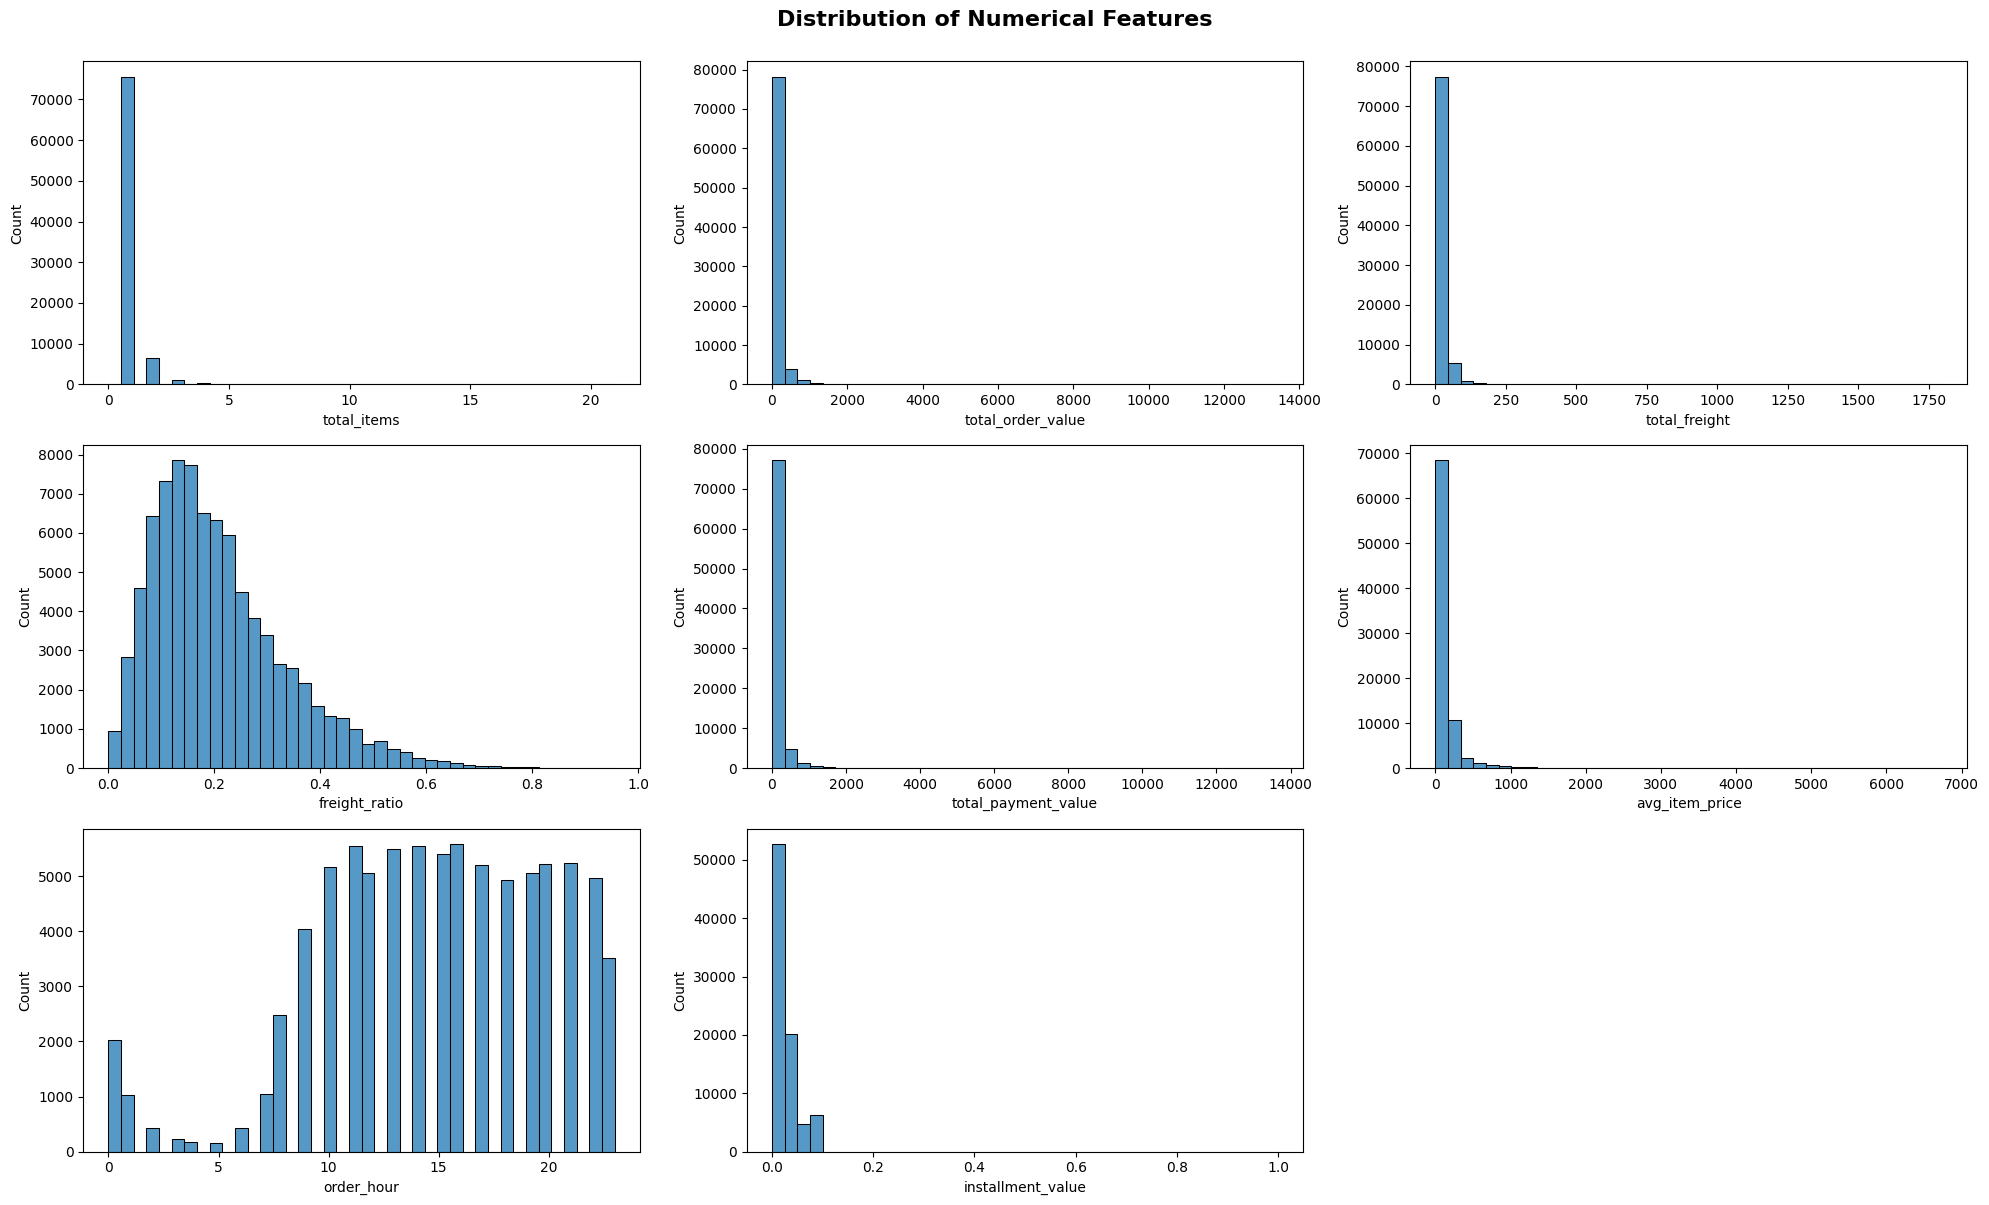

In [25]:
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (20, 12)) # create 2x3 subplots

# initial value for axes
nrow = 0
ncol = 0

for col in num_col:

    # set axes
    ax = axes[nrow, ncol]

    # histogram plot to see distribution
    # use df since on EDA section
    sns.histplot(X_train_log[col], bins = 40, ax = ax)
    ax.set_xlabel(col)

    ncol += 1 # increase the ncol

    # ncol should only 0, 1, or 2
    # if after increment earlier reached 3
    if ncol == 3: 
        ncol = 0 # reset to 0
        nrow += 1 # next row

# turned off unused axis
axes[2, 2].axis('off')

# display the plot and styling
fig.suptitle('Distribution of Numerical Features', fontsize = 16, fontweight = 'bold', y = 1)
plt.tight_layout()
plt.show()

In [26]:
def check_skewness(df, *column_names):
    return {col: df[col].skew() for col in column_names if col in df.columns}

skewness_results = check_skewness(X_train_log, 'total_order_value','total_freight','freight_ratio'
                                  ,'total_payment_value','avg_item_price','order_hour','installment_value')

for col, skewness in skewness_results.items():
    print(f"{col}: {skewness}")

total_order_value: 10.197629710819413
total_freight: 12.803224597834035
freight_ratio: 1.061318278691629
total_payment_value: 9.647051133900884
avg_item_price: 7.757916987399946
order_hour: -0.6056853225482431
installment_value: 3.1106932591880003


reasoning

---

In [27]:
log_transform_col = ['total_order_value','total_freight','avg_item_price','total_payment_value','installment_value']

for cols in log_transform_col:
    X_train_log[cols] = np.log1p(X_train[cols])

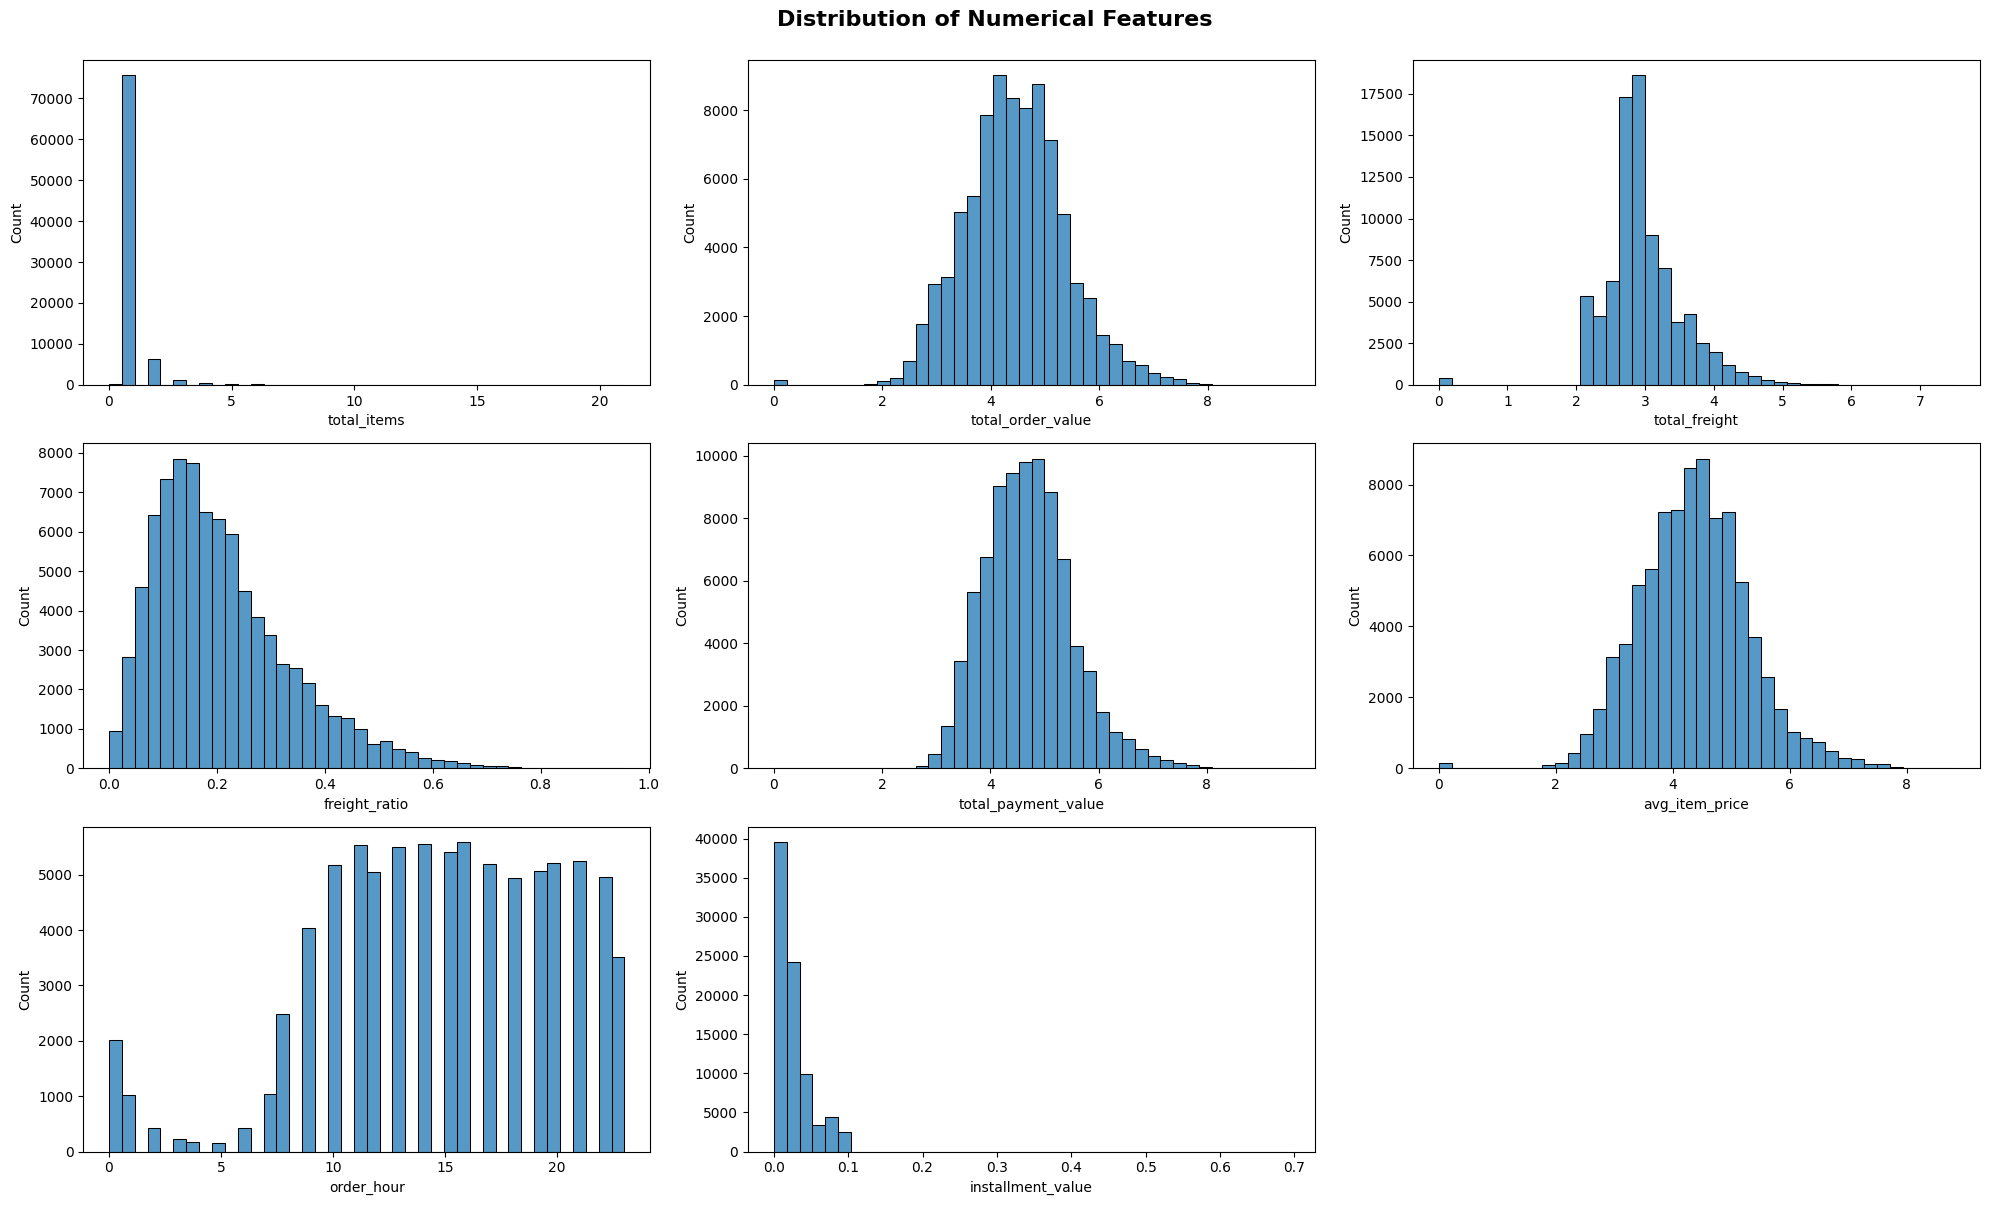

In [28]:
fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (20, 12)) # create 2x3 subplots

# initial value for axes
nrow = 0
ncol = 0

for col in num_col:

    # set axes
    ax = axes[nrow, ncol]

    # histogram plot to see distribution
    # use df since on EDA section
    sns.histplot(X_train_log[col], bins = 40, ax = ax)
    ax.set_xlabel(col)

    ncol += 1 # increase the ncol

    # ncol should only 0, 1, or 2
    # if after increment earlier reached 3
    if ncol == 3: 
        ncol = 0 # reset to 0
        nrow += 1 # next row

# turned off unused axis
axes[2, 2].axis('off')


# display the plot and styling
fig.suptitle('Distribution of Numerical Features', fontsize = 16, fontweight = 'bold', y = 1)
plt.tight_layout()
plt.show()

In [29]:
skewness_results = check_skewness(X_train_log, 'total_order_value','total_freight','avg_item_price'
                                  ,'total_payment_value','freight_ratio','order_hour','installment_value')

for col, skewness in skewness_results.items():
    print(f"{col}: {skewness}")

total_order_value: 0.10351598549643216
total_freight: 0.22001183204816258
avg_item_price: 0.1326419520723578
total_payment_value: 0.540406205560192
freight_ratio: 1.061318278691629
order_hour: -0.6056853225482431
installment_value: 2.063946196409708


In [30]:
normal_skewed_columns = ['total_order_value','total_freight','avg_item_price']
moderate_skewed_columns = ['total_payment_value','order_hour']
extreme_skewed_columns = ['installment_value','freight_ratio']

print(f"Normal Skewed: {normal_skewed_columns}")
print(f"Moderate Skewed: {moderate_skewed_columns}")
print(f"Extreme Skewed: {extreme_skewed_columns}")

Normal Skewed: ['total_order_value', 'total_freight', 'avg_item_price']
Moderate Skewed: ['total_payment_value', 'order_hour']
Extreme Skewed: ['installment_value', 'freight_ratio']


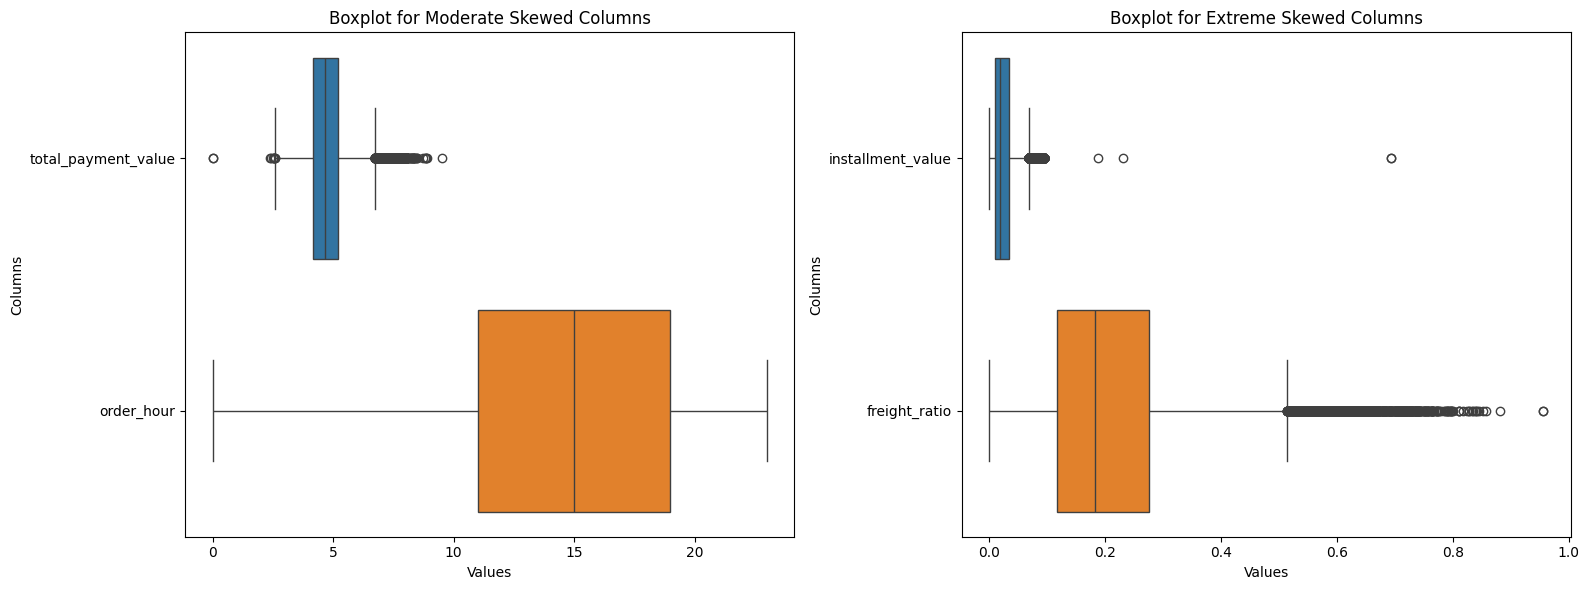

In [31]:
# Create a figure and two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # menampilkan grafik 1 baris 2 kolom

# Boxplot for skewed columns
sns.boxplot(data=X_train_log[moderate_skewed_columns], orient="h", ax=axes[0])
axes[0].set_title("Boxplot for Moderate Skewed Columns")
axes[0].set_xlabel("Values")
axes[0].set_ylabel("Columns")

# Boxplot for extreme skewed columns
sns.boxplot(data=X_train_log[extreme_skewed_columns], orient="h", ax=axes[1])
axes[1].set_title("Boxplot for Extreme Skewed Columns")
axes[1].set_xlabel("Values")
axes[1].set_ylabel("Columns")

# Display the plot
plt.tight_layout()
plt.show()

In [32]:
def apply_winsorization_moderate_skew(train, variables, capping_method='iqr', tail='both', fold=1.5):
    winsoriser = Winsorizer(capping_method=capping_method, tail=tail, fold=fold, variables=variables)
    train_capped = winsoriser.fit_transform(train)
    return train_capped

def apply_winsorization_extreme_skew(train, variables, capping_method='iqr', tail='both', fold=3):
    winsoriser = Winsorizer(capping_method=capping_method, tail=tail, fold=fold, variables=variables)
    train_capped = winsoriser.fit_transform(train)
    return train_capped


# Apply to X_train column
X_train_log = apply_winsorization_moderate_skew(X_train_log, moderate_skewed_columns)
X_train_log = apply_winsorization_extreme_skew(X_train_log, extreme_skewed_columns)

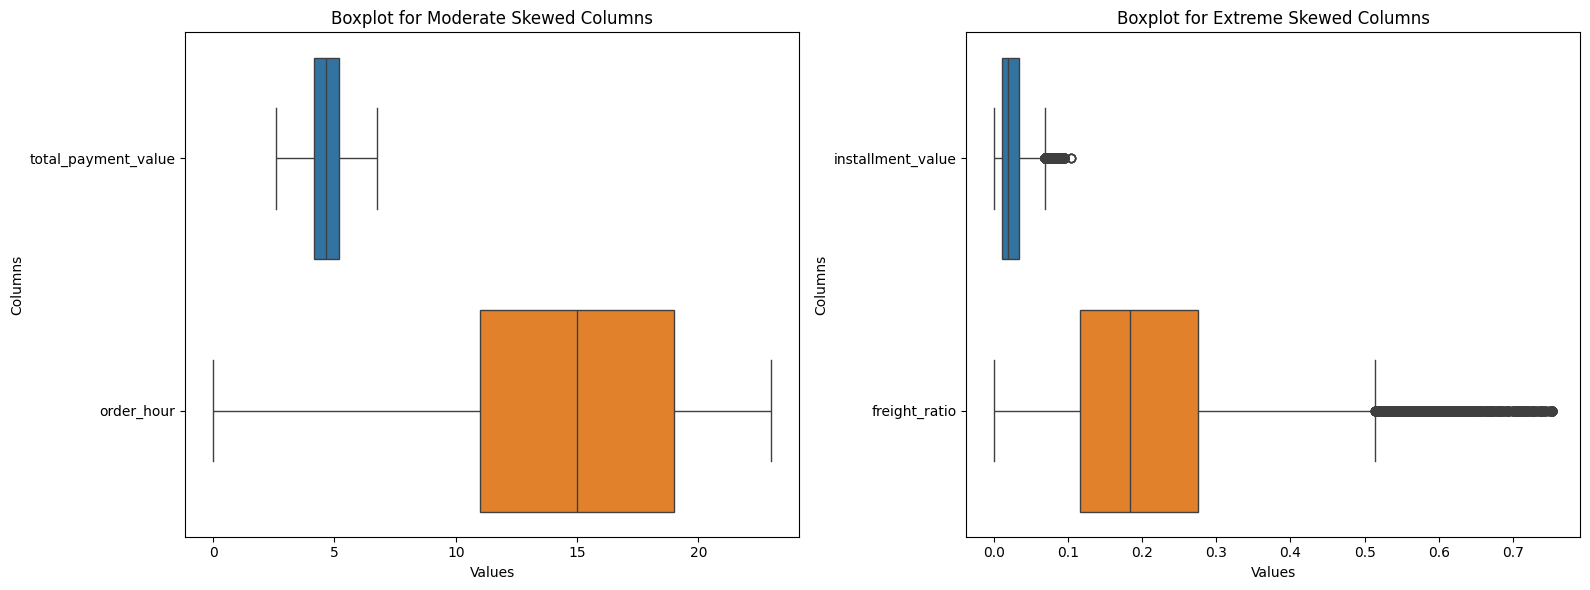

In [33]:
# Create a figure and two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # menampilkan grafik 1 baris 2 kolom

# Boxplot for skewed columns
sns.boxplot(data=X_train_log[moderate_skewed_columns], orient="h", ax=axes[0])
axes[0].set_title("Boxplot for Moderate Skewed Columns")
axes[0].set_xlabel("Values")
axes[0].set_ylabel("Columns")

# Boxplot for extreme skewed columns
sns.boxplot(data=X_train_log[extreme_skewed_columns], orient="h", ax=axes[1])
axes[1].set_title("Boxplot for Extreme Skewed Columns")
axes[1].set_xlabel("Values")
axes[1].set_ylabel("Columns")

# Display the plot
plt.tight_layout()
plt.show()

---
### Zero Inflated Handling

---

In [34]:
# create binning for `total_items` column
X_train_log['total_items_bin'] = pd.cut(
    X_train['total_items']
    ,bins=[-1, 0, 1, 3, 5, 1000] # 5 binning
    ,labels=['no_item','single','few','several','bulk']
    ,include_lowest=True
)
X_train_bin = X_train_log.drop('total_items',axis=1)

X_train['total_items_bin'] = pd.cut(
    X_train['total_items']
    ,bins=[-1, 0, 1, 3, 5, 1000] # 5 binning
    ,labels=['no_item','single','few','several','bulk']
    ,include_lowest=True
)

X_test['total_items_bin'] = pd.cut(
    X_test['total_items']
    ,bins=[-1, 0, 1, 3, 5, 1000] # 5 binning
    ,labels=['no_item','single','few','several','bulk']
    ,include_lowest=True
)
X_test_bin = X_test.drop('total_items',axis=1)

---
## Feature Selection

---


in this section feature will be retained or removed based on correlation result when checking with phik matrix

In [35]:
concat_data = pd.concat([X_train_bin, y_train], axis=1)

concat_data.head()

,total_order_value,total_freight,avg_item_price,payment_type,total_payment_value,max_installments,customer_state,installment_bin,installment_value,days_of_week,is_weekend,order_hour,freight_ratio,total_items_bin,is_canceled
46783,3.039749,2.553344,3.039749,credit_card,3.488903,1.0,SP,very_short,0.030077,1,0,13,0.373228,single,0
43339,3.493473,2.778819,3.493473,boleto,3.871201,1.0,SP,very_short,0.020619,1,0,13,0.321277,single,0
52087,5.560682,2.832036,5.560682,credit_card,5.620328,1.0,MG,very_short,0.003617,6,1,9,0.058113,single,0
41300,4.764990,3.672750,4.764990,boleto,5.047867,1.0,RS,very_short,0.006402,2,0,8,0.247980,single,0
76970,4.605170,2.345645,4.605170,credit_card,4.695376,5.0,SP,very_short,0.044674,2,0,18,0.087053,single,0


In [36]:
interval_cols = [
    'total_order_value'
    ,'total_freight'
    ,'avg_item_price'
    ,'total_payment_value'
    ,'freight_ratio'
    ,'installment_value'
    ,'order_hour'
]
corr_check = concat_data.phik_matrix(interval_cols=interval_cols)

corr_check['is_canceled'].sort_values(ascending=False)

is_canceled            1.000000
total_order_value      0.638119
avg_item_price         0.638019
total_items_bin        0.409113
total_freight          0.289921
freight_ratio          0.094353
payment_type           0.071520
total_payment_value    0.023985
customer_state         0.022257
installment_value      0.020288
max_installments       0.008998
order_hour             0.007184
days_of_week           0.001480
installment_bin        0.000000
is_weekend             0.000000
Name: is_canceled, dtype: float64

feature with correlation under 1% (0.01) will be removed

---

In [37]:
# Final categorical columns & numerical columns
ord_col_fin = ['total_items_bin']
cat_col_fin = ['customer_state']

num_nor_col_fin = ['total_order_value','total_freight','avg_item_price']
# num_mod_col_fin = ['total_payment_value']
# num_ext_col_fin = ['freight_ratio']


In [38]:
X_train_num_nor = X_train[num_nor_col_fin]
# X_train_num_mod = X_train[num_mod_col_fin]
# X_train_num_ext = X_train[num_ext_col_fin]
X_train_cat = X_train[cat_col_fin]
X_train_ord = X_train[ord_col_fin]

X_test_num_nor = X_test[num_nor_col_fin]
# X_test_num_mod = X_test[num_mod_col_fin]
# X_test_num_ext = X_test[num_ext_col_fin]
X_test_cat = X_test[cat_col_fin]
X_test_ord = X_test[ord_col_fin]

X_train_num_nor.head()

,total_order_value,total_freight,avg_item_price
46783,3.039749,2.553344,3.039749
43339,3.493473,2.778819,3.493473
52087,5.560682,2.832036,5.560682
41300,4.764990,3.672750,4.764990
76970,4.605170,2.345645,4.605170


In [39]:
# X_train_num_mod.head()

In [40]:
# X_train_num_ext.head()

In [41]:
X_train_cat.head()

,customer_state
46783,SP
43339,SP
52087,MG
41300,RS
76970,SP


In [42]:
X_train_ord.head()

,total_items_bin
46783,single
43339,single
52087,single
41300,single
76970,single


---
## Feature Scaling

---

In [43]:
# standar scaler
STscaler = StandardScaler()

STscaler.fit(X_train_num_nor)

# min max scaler
# MMscaler_mod = MinMaxScaler()
# MMscaler_ext = MinMaxScaler()

# MMscaler_mod.fit(X_train_num_mod)
# MMscaler_ext.fit(X_train_num_ext)


X_train_num_nor_scaled = STscaler.transform(X_train_num_nor)
# X_train_num_mod_scaled = MMscaler_mod.transform(X_train_num_mod)
# X_train_num_ext_scaled = MMscaler_ext.transform(X_train_num_ext)

X_test_num_nor_scaled = STscaler.transform(X_test_num_nor)
# X_test_num_mod_scaled = MMscaler_mod.transform(X_test_num_mod)
# X_test_num_ext_scaled = MMscaler_ext.transform(X_test_num_ext)


---
## Feature Encoding

---

In [44]:
encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
X_train_cat_final = encoder.fit_transform(X_train_cat)
X_test_cat_final = encoder.transform(X_test_cat)

In [45]:
ord_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_ord_final = encoder.fit_transform(X_train_ord)
X_test_ord_final = encoder.transform(X_test_ord)

---
## Finalize Train Test column

---

In [46]:
# Menggabungkan data kategori dan angka
X_train_final = np.concatenate([ X_train_num_nor_scaled
                                # ,X_train_num_mod_scaled
                                # ,X_train_num_ext_scaled
                                ,X_train_cat_final
                                ,X_train_ord_final], axis=1)
X_test_final = np.concatenate([  X_test_num_nor_scaled
                                # ,X_test_num_mod_scaled
                                # ,X_test_num_ext_scaled
                                ,X_test_cat_final
                                ,X_test_ord_final], axis=1)

In [47]:
X_train_final_df = pd.DataFrame(X_train_final)

X_train_final_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,-1.509637,-0.754451,-1.442195,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,-1.024856,-0.358096,-0.950864,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1.183854,-0.264549,1.287690,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.333697,1.213309,0.426047,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.162937,-1.119557,0.252979,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [48]:
X_test_final_df = pd.DataFrame(X_test_final)

X_test_final_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,79.650109,26.047033,80.814197,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,33.599905,7.958656,34.141754,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,94.501567,31.619449,95.866331,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,134.034225,26.679863,135.933162,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,134.141070,51.746943,65.653775,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


---
# Modeling

---

In [49]:
def function_total_items_bin(X):
    X = X.copy()
    X['total_items_bin'] = pd.cut(
        X['total_items'],
        bins=[-1, 0, 1, 3, 5, 1000],
        labels=['no_item','single','few','several','bulk'],
        include_lowest=True
    )
    return X

In [50]:
log_transformer = FunctionTransformer(
    np.log1p,
    feature_names_out='one-to-one'
)

num_nor_pipe = make_pipeline(
    SimpleImputer(strategy='constant', fill_value=0)
    ,log_transformer
    ,Winsorizer(capping_method='gaussian', tail='both', fold=3)
    ,StandardScaler()
)

# num_mod_pipe = make_pipeline(
#     SimpleImputer(strategy='constant', fill_value=0)
#     ,log_transformer
#     ,Winsorizer(capping_method='iqr', tail='both', fold=1.5)
#     ,MinMaxScaler()
# )

# num_ext_pipe = make_pipeline(
#     SimpleImputer(strategy='constant', fill_value=0)
#     ,log_transformer
#     ,Winsorizer(capping_method='iqr', tail='both', fold=3)
#     ,MinMaxScaler()
# )

cat_pipe = make_pipeline(
    OneHotEncoder(handle_unknown='ignore',sparse_output=False)
)

ord_pipe = make_pipeline(
    OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num_nor_col',num_nor_pipe,num_nor_col_fin)
        # ,('num_mod_col',num_mod_pipe,num_mod_col_fin)
        # ,('num_ext_col',num_ext_pipe,num_ext_col_fin)
        ,('cat_col',cat_pipe,cat_col_fin)
        ,('ord_col',ord_pipe,ord_col_fin)
    ],remainder='drop'
    ,verbose_feature_names_out=True
)

preprocessor

ColumnTransformer(transformers=[('num_nor_col',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value=0,
                                                                strategy='constant')),
                                                 ('functiontransformer',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>)),
                                                 ('winsorizer',
                                                  Winsorizer(fold=3,
                                                             tail='both')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['total_order_value', 'total_freight',
                                  'avg_item_price']),
                                ('cat_col',
                                 Pipeline(steps=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['customer_state']),
                                ('ord_col',
                                 Pipeline(steps=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                                 ['total_items_bin'])])

In [51]:
base_pipeline = make_pipeline(
    FunctionTransformer(function_total_items_bin, validate=False, feature_names_out="one-to-one")
    ,preprocessor
)

In [52]:
cancel = (y_train == 1).sum()
no_cancel = (y_train == 0).sum()
scale = no_cancel / cancel
random = 42


pipe_log = make_pipeline(
    base_pipeline,LogisticRegression(
        random_state=random
        ,max_iter=1000
        ,class_weight='balanced')
        )

pipe_rf  = make_pipeline(
    base_pipeline,RandomForestClassifier(
        random_state=random
        ,class_weight='balanced')
        )

pipe_XGB = make_pipeline(
    base_pipeline,XGBClassifier(
        random_state=random
        ,scale_pos_weight=scale)
        )

pipe_LGB = make_pipeline(
    base_pipeline,LGBMClassifier(
        random_state=random
        ,scale_pos_weight=scale)
        )

---
# Model Training

---

In [53]:
skfold = StratifiedKFold(n_splits = 5) 

cv_log_model = cross_val_score(pipe_log, X_train, y_train, cv = skfold, scoring='recall', n_jobs=-1)
cv_rf_model  = cross_val_score(pipe_rf , X_train, y_train, cv = skfold, scoring='recall', n_jobs=-1)
cv_XGB_model = cross_val_score(pipe_XGB, X_train, y_train, cv = skfold, scoring='recall', n_jobs=-1)
cv_LGB_model = cross_val_score(pipe_LGB, X_train, y_train, cv = skfold, scoring='recall', n_jobs=-1)

---
# Model Evaluation

---

---
## Model Evaluation with Recall Score

---

In [54]:
name_model = []
cv_scores = 0
for cv,name in zip([cv_log_model,cv_rf_model,cv_XGB_model,cv_LGB_model],
                   ['log_model','rf_model','XGB_model','LGB_model']):
  print(name)
  print('average_precision - All - Cross Validation :', cv)
  print('average_precision - Mean - Cross Validation :', cv.mean())
  print('average_precision - std - Cross Validation :', cv.std())
  print('average_precision - Range of Test Set :', (cv.mean()-cv.std()), '-' , (cv.mean()+cv.std()))
  print('-'*100)
  if cv.mean() > cv_scores:
    cv_scores = cv.mean()
    name_model = name
  else:
    pass

print('Best Model:', name_model)
print('Cross Val Mean from Best Model:', cv_scores)

log_model
average_precision - All - Cross Validation : [0.56074766 0.45283019 0.5        0.5754717  0.56603774]
average_precision - Mean - Cross Validation : 0.5310174572385822
average_precision - std - Cross Validation : 0.04724789144800946
average_precision - Range of Test Set : 0.48376956579057273 - 0.5782653486865916
----------------------------------------------------------------------------------------------------
rf_model
average_precision - All - Cross Validation : [0.35514019 0.21698113 0.32075472 0.33018868 0.30188679]
average_precision - Mean - Cross Validation : 0.304990301534121
average_precision - std - Cross Validation : 0.04723077749705926
average_precision - Range of Test Set : 0.2577595240370617 - 0.3522210790311803
----------------------------------------------------------------------------------------------------
XGB_model
average_precision - All - Cross Validation : [0.40186916 0.27358491 0.38679245 0.38679245 0.36792453]
average_precision - Mean - Cross Validation

---
## Trade off

---

In [55]:
y_prob_log = cross_val_predict(pipe_log,X_train,y_train,cv=skfold,method='predict_proba',n_jobs=-1)[:, 1]
y_prob_rf  = cross_val_predict(pipe_rf ,X_train,y_train,cv=skfold,method='predict_proba',n_jobs=-1)[:, 1]
y_prob_XGB = cross_val_predict(pipe_XGB,X_train,y_train,cv=skfold,method='predict_proba',n_jobs=-1)[:, 1]
y_prob_LGB = cross_val_predict(pipe_LGB,X_train,y_train,cv=skfold,method='predict_proba',n_jobs=-1)[:, 1]

In [56]:
thresholds_log = np.linspace(0.1, 0.8, 20)

row_log = []

for t in thresholds_log:
    y_pred_t = (y_prob_log >= t).astype(int)
    
    row_log.append({
        "model" : 'Logistic Regression'
        ,"tuning" : 'no'
        ,"threshold": round(float(t), 4)
        ,"precision": precision_score(y_train, y_pred_t, zero_division=0)
        ,"recall": recall_score(y_train, y_pred_t, zero_division=0)
        ,"f1": f1_score(y_train, y_pred_t, zero_division=0)
    })

results_log = pd.DataFrame(row_log)

results_log.sort_values("recall", ascending=False)

,model,tuning,threshold,precision,recall,f1
0,Logistic Regression,no,0.1000,0.006297,0.994350,0.012515
1,Logistic Regression,no,0.1368,0.006289,0.988701,0.012498
2,Logistic Regression,no,0.1737,0.006313,0.983051,0.012546
3,Logistic Regression,no,0.2105,0.006347,0.967985,0.012612
4,Logistic Regression,no,0.2474,0.006321,0.932203,0.012557
5,Logistic Regression,no,0.2842,0.006423,0.902072,0.012755
6,Logistic Regression,no,0.3211,0.006649,0.868173,0.013197
7,Logistic Regression,no,0.3579,0.007083,0.834275,0.014046
8,Logistic Regression,no,0.3947,0.007672,0.783427,0.015195
9,Logistic Regression,no,0.4316,0.008657,0.717514,0.017107


In [57]:
thresholds_rf = np.linspace(0.001, 0.2, 20)

row_rf = []

for t in thresholds_rf:
    y_pred_t = (y_prob_rf >= t).astype(int)
    
    row_rf.append({
        "model" : 'Random Forest'
        ,"tuning" : 'no'
        ,"threshold": round(float(t), 4)
        ,"precision": precision_score(y_train, y_pred_t, zero_division=0)
        ,"recall": recall_score(y_train, y_pred_t, zero_division=0)
        ,"f1": f1_score(y_train, y_pred_t, zero_division=0)
    })

results_rf = pd.DataFrame(row_rf)

results_rf.sort_values("recall", ascending=False)

,model,tuning,threshold,precision,recall,f1
0,Random Forest,no,0.0010,0.030680,0.376648,0.056738
1,Random Forest,no,0.0115,0.044662,0.352166,0.079271
2,Random Forest,no,0.0219,0.054436,0.340866,0.093880
3,Random Forest,no,0.0324,0.062964,0.335217,0.106015
4,Random Forest,no,0.0429,0.069130,0.327684,0.114173
5,Random Forest,no,0.0534,0.075718,0.327684,0.123012
6,Random Forest,no,0.0638,0.082543,0.327684,0.131868
7,Random Forest,no,0.0743,0.087398,0.323917,0.137655
8,Random Forest,no,0.0848,0.092873,0.323917,0.144356
9,Random Forest,no,0.0953,0.098342,0.323917,0.150877


In [58]:
thresholds_XGB = np.linspace(0.001, 0.2, 20)

row_XGB = []

for t in thresholds_XGB:
    y_pred_t = (y_prob_XGB >= t).astype(int)
    
    row_XGB.append({
        "model" : 'XGBoost'
        ,"tuning" : 'no'
        ,"threshold": round(float(t), 4)
        ,"precision": precision_score(y_train, y_pred_t, zero_division=0)
        ,"recall": recall_score(y_train, y_pred_t, zero_division=0)
        ,"f1": f1_score(y_train, y_pred_t, zero_division=0)
    })

results_XGB = pd.DataFrame(row_XGB)

results_XGB.sort_values("recall", ascending=False)

,model,tuning,threshold,precision,recall,f1
0,XGBoost,no,0.0010,0.006442,0.975518,0.012799
1,XGBoost,no,0.0115,0.007152,0.868173,0.014187
2,XGBoost,no,0.0219,0.007626,0.802260,0.015109
3,XGBoost,no,0.0324,0.007960,0.743879,0.015751
4,XGBoost,no,0.0429,0.008472,0.713748,0.016746
5,XGBoost,no,0.0534,0.008980,0.689266,0.017730
6,XGBoost,no,0.0638,0.009212,0.651601,0.018167
7,XGBoost,no,0.0743,0.009655,0.632768,0.019021
8,XGBoost,no,0.0848,0.010118,0.615819,0.019909
9,XGBoost,no,0.0953,0.010581,0.602637,0.020796


In [59]:
thresholds_LGB = np.linspace(0.01, 0.5, 20)

row_LGB = []

for t in thresholds_LGB:
    y_pred_t = (y_prob_LGB >= t).astype(int)
    
    row_LGB.append({
        "model" : 'LGBoost'
        ,"tuning" : 'no'
        ,"threshold": round(float(t), 4)
        ,"precision": precision_score(y_train, y_pred_t, zero_division=0)
        ,"recall": recall_score(y_train, y_pred_t, zero_division=0)
        ,"f1": f1_score(y_train, y_pred_t, zero_division=0)
    })

results_LGB = pd.DataFrame(row_LGB)

results_LGB.sort_values("recall", ascending=False)

,model,tuning,threshold,precision,recall,f1
0,LGBoost,no,0.0100,0.007136,0.841808,0.014153
1,LGBoost,no,0.0358,0.007536,0.766478,0.014926
2,LGBoost,no,0.0616,0.007945,0.728814,0.015719
3,LGBoost,no,0.0874,0.008359,0.700565,0.016521
4,LGBoost,no,0.1132,0.008808,0.674200,0.017389
5,LGBoost,no,0.1389,0.009407,0.657250,0.018548
6,LGBoost,no,0.1647,0.010031,0.636535,0.019751
7,LGBoost,no,0.1905,0.010783,0.617702,0.021196
8,LGBoost,no,0.2163,0.011658,0.600753,0.022871
9,LGBoost,no,0.2421,0.012541,0.583804,0.024555


In [60]:
# comparation all model with recall over 80%
target_results_log = results_log.loc[[7]]
target_results_rf  = results_rf.loc[[0]]
target_results_XGB = results_XGB.loc[[1]]
target_results_LGB = results_LGB.loc[[0]]

result_all = pd.concat(
    [target_results_log
     ,target_results_rf
     ,target_results_XGB
     ,target_results_LGB], ignore_index=True)

result_all 

,model,tuning,threshold,precision,recall,f1
0,Logistic Regression,no,0.3579,0.007083,0.834275,0.014046
1,Random Forest,no,0.0010,0.030680,0.376648,0.056738
2,XGBoost,no,0.0115,0.007152,0.868173,0.014187
3,LGBoost,no,0.0100,0.007136,0.841808,0.014153


reasoning :

---

---
## Hyperparameter Tuning

---

In [61]:
param_grid = {
    'logisticregression__C': [0.01, 0.1, 1, 10, 100]
    ,'logisticregression__penalty': ['l1', 'l2']
}

grid_log = GridSearchCV(
     pipe_log
    ,param_grid
    ,cv=skfold
    ,scoring='recall'
    ,n_jobs=-1
    ,verbose=1
)

grid_log.fit(X_train, y_train)

best_log = grid_log.best_estimator_

print('Best hyperparameters for Logistic regression:', grid_log.best_params_)

print('Best Score for Logistic regression:', grid_log.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best hyperparameters for Logistic regression: {'logisticregression__C': 1, 'logisticregression__penalty': 'l2'}
Best Score for Logistic regression: 0.5310174572385822


In [62]:
# Predict with model after tuning
y_prob_ht_log = cross_val_predict(best_log,X_train,y_train,cv=skfold,method='predict_proba',n_jobs=-1)[:, 1]

# set Threshold from 0.1 to 0.8 into 20 rows
thresholds_ht_log = np.linspace(0.1, 0.8, 20)

row_ht_log = []

for t in thresholds_log:
    y_pred_t = (y_prob_ht_log >= t).astype(int)
    
    row_ht_log.append({
        "model" : 'Logistic Regression'
        ,"tuning" : 'yes'
        ,"threshold": round(float(t), 4)
        ,"precision": precision_score(y_train, y_pred_t, zero_division=0)
        ,"recall": recall_score(y_train, y_pred_t, zero_division=0)
        ,"f1": f1_score(y_train, y_pred_t, zero_division=0)
    })

results_ht_log = pd.DataFrame(row_ht_log)

results_ht_log.sort_values("recall", ascending=False)

,model,tuning,threshold,precision,recall,f1
0,Logistic Regression,yes,0.1000,0.006297,0.994350,0.012515
1,Logistic Regression,yes,0.1368,0.006289,0.988701,0.012498
2,Logistic Regression,yes,0.1737,0.006313,0.983051,0.012546
3,Logistic Regression,yes,0.2105,0.006347,0.967985,0.012612
4,Logistic Regression,yes,0.2474,0.006321,0.932203,0.012557
5,Logistic Regression,yes,0.2842,0.006423,0.902072,0.012755
6,Logistic Regression,yes,0.3211,0.006649,0.868173,0.013197
7,Logistic Regression,yes,0.3579,0.007083,0.834275,0.014046
8,Logistic Regression,yes,0.3947,0.007672,0.783427,0.015195
9,Logistic Regression,yes,0.4316,0.008657,0.717514,0.017107


In [63]:
target_results_log = results_log.loc[[7]]
target_results_ht_log  = results_ht_log.loc[[7]]

result_all_log = pd.concat(
    [target_results_log
     ,target_results_ht_log], ignore_index=True)

result_all_log

,model,tuning,threshold,precision,recall,f1
0,Logistic Regression,no,0.3579,0.007083,0.834275,0.014046
1,Logistic Regression,yes,0.3579,0.007083,0.834275,0.014046


---
## Model Evaluation Confusion Matrix

---

[LightGBM] [Info] Number of positive: 531, number of negative: 83475
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000846 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 790
[LightGBM] [Info] Number of data points in the train set: 84006, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.006321 -> initscore=-5.057540
[LightGBM] [Info] Start training from score -5.057540


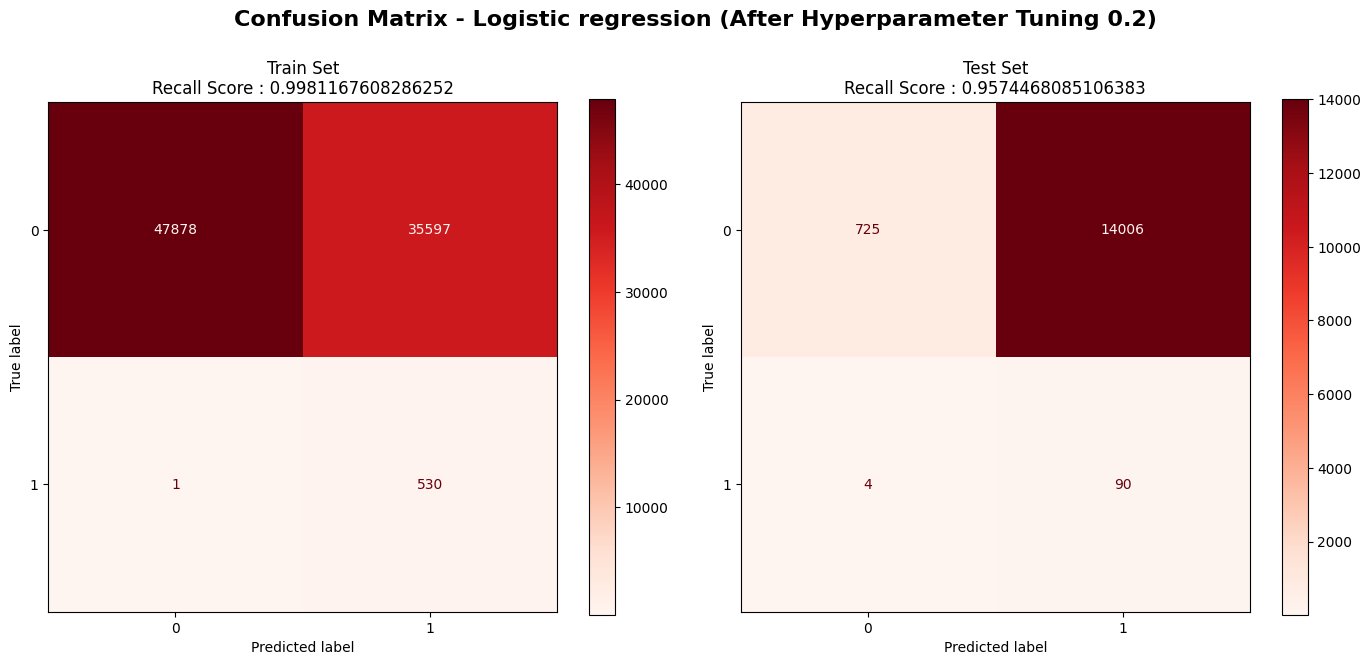

In [64]:
# Super Model
threshold = 0.2

# fit with overall train set
pipe_LGB.fit(X_train, y_train)

y_proba_train = pipe_LGB.predict_proba(X_train)[:,1]
y_proba_test = pipe_LGB.predict_proba(X_test)[:,1]

y_pred_train_log = (y_proba_train >= threshold).astype(int)
y_pred_test_log = (y_proba_test >= threshold).astype(int)

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (14,6)) # create figure 1x2

# confusion matrix - train set
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train_log, cmap = 'Reds', ax = axes[0]) # left side
axes[0].set_title('Train Set\n' + f'Recall Score : {recall_score(y_train, y_pred_train_log)}')

# confusion matrix - test set
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_log, cmap = 'Reds', ax = axes[1]) # right side
axes[1].set_title('Test Set\n' + f'Recall Score : {recall_score(y_test, y_pred_test_log)}')

# display the plot and styling
fig.suptitle(f'Confusion Matrix - Logistic regression (After Hyperparameter Tuning {threshold})', fontsize = 16, weight = 'bold', y = 1.05) # y for space
plt.tight_layout()
plt.show()

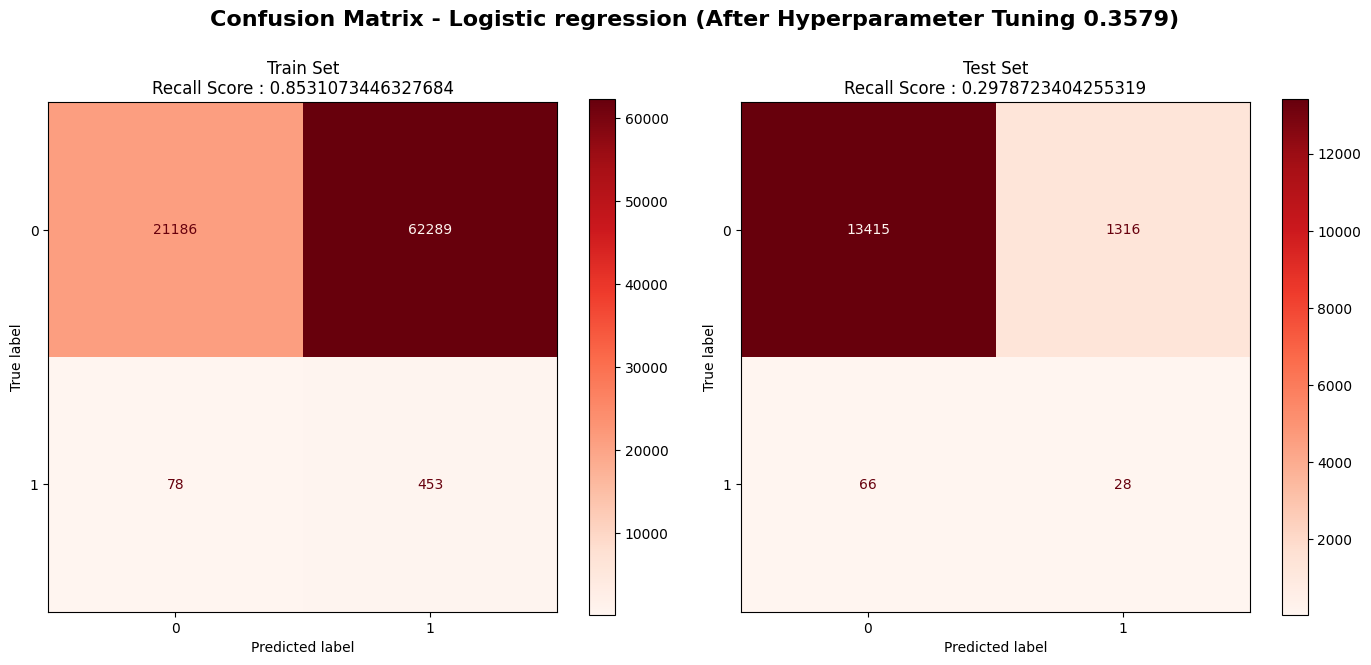

In [65]:
# Super Model
threshold = 0.3579

# fit with overall train set
pipe_log.fit(X_train, y_train)

y_proba_train = pipe_log.predict_proba(X_train)[:,1]
y_proba_test = pipe_log.predict_proba(X_test)[:,1]

y_pred_train_log = (y_proba_train >= threshold).astype(int)
y_pred_test_log = (y_proba_test >= threshold).astype(int)

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (14,6)) # create figure 1x2

# confusion matrix - train set
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train_log, cmap = 'Reds', ax = axes[0]) # left side
axes[0].set_title('Train Set\n' + f'Recall Score : {recall_score(y_train, y_pred_train_log)}')

# confusion matrix - test set
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_log, cmap = 'Reds', ax = axes[1]) # right side
axes[1].set_title('Test Set\n' + f'Recall Score : {recall_score(y_test, y_pred_test_log)}')

# display the plot and styling
fig.suptitle(f'Confusion Matrix - Logistic regression (After Hyperparameter Tuning {threshold})', fontsize = 16, weight = 'bold', y = 1.05) # y for space
plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

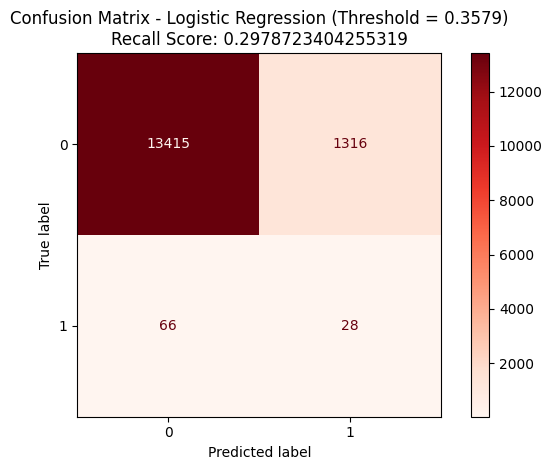

In [66]:
threshold = 0.3579

pipe_log.fit(X_train, y_train)

y_proba_test = pipe_log.predict_proba(X_test)[:,1]

y_pred_test_log = (y_proba_test >= threshold).astype(int)

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test_log,cmap='Reds')
plt.title(f'Confusion Matrix - Logistic Regression (Threshold = {threshold})\nRecall Score: {recall_score(y_test, y_pred_test_log)}')
plt.tight_layout()
plt.show()

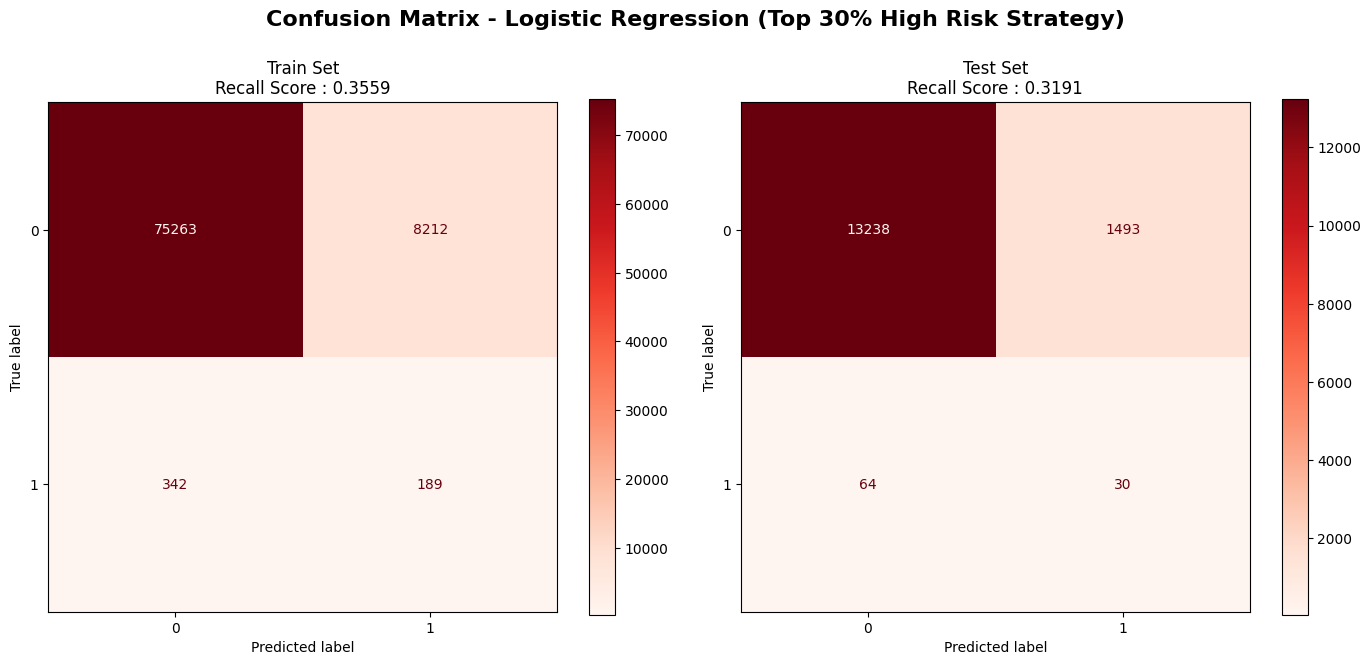

In [75]:
# threshold based on top 10%
pipe_log.fit(X_train, y_train)

y_proba_train = pipe_log.predict_proba(X_train)[:,1]
y_proba_test = pipe_log.predict_proba(X_test)[:,1]

threshold_train = np.percentile(y_proba_train, 90)
threshold_test = np.percentile(y_proba_test, 90)

y_pred_train_log = (y_proba_train >= threshold_train).astype(int)
y_pred_test_log = (y_proba_test >= threshold_test).astype(int)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14,6))

ConfusionMatrixDisplay.from_predictions(y_train,y_pred_train_log,cmap="Reds",ax=axes[0])
axes[0].set_title("Train Set\n"+ "Recall Score : "+ str(round(recall_score(y_train, y_pred_train_log),4)))

# test confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test_log,cmap="Reds",ax=axes[1])
axes[1].set_title("Test Set\n"+ "Recall Score : "+ str(round(recall_score(y_test, y_pred_test_log),4)))

fig.suptitle("Confusion Matrix - Logistic Regression (Top 30% High Risk Strategy)",fontsize=16,weight="bold",y=1.05)

plt.tight_layout()
plt.show()

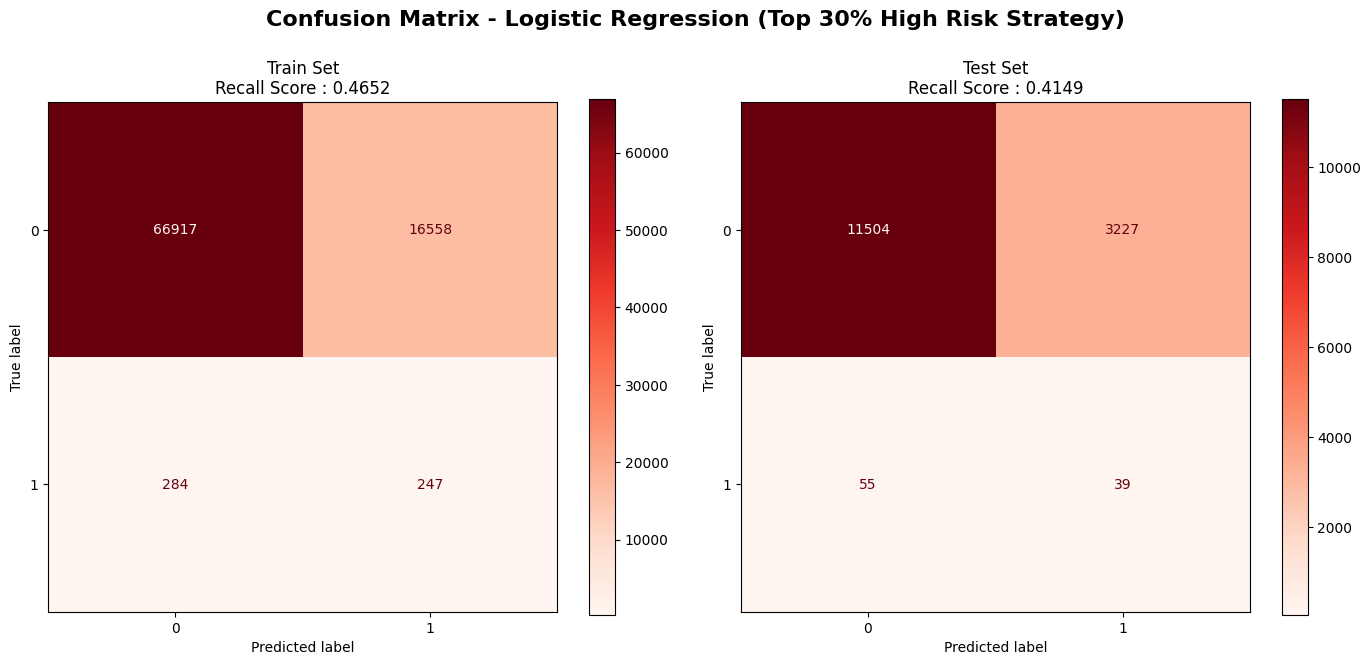

In [76]:
#threshold based on top 20%
pipe_log.fit(X_train, y_train)

y_proba_train = pipe_log.predict_proba(X_train)[:,1]
y_proba_test = pipe_log.predict_proba(X_test)[:,1]

threshold_train = np.percentile(y_proba_train, 80)
threshold_test = np.percentile(y_proba_test, 80)

y_pred_train_log = (y_proba_train >= threshold_train).astype(int)
y_pred_test_log = (y_proba_test >= threshold_test).astype(int)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14,6))

ConfusionMatrixDisplay.from_predictions(y_train,y_pred_train_log,cmap="Reds",ax=axes[0])
axes[0].set_title("Train Set\n"+ "Recall Score : "+ str(round(recall_score(y_train, y_pred_train_log),4)))

# test confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test_log,cmap="Reds",ax=axes[1])
axes[1].set_title("Test Set\n"+ "Recall Score : "+ str(round(recall_score(y_test, y_pred_test_log),4)))

fig.suptitle("Confusion Matrix - Logistic Regression (Top 30% High Risk Strategy)",fontsize=16,weight="bold",y=1.05)

plt.tight_layout()
plt.show()

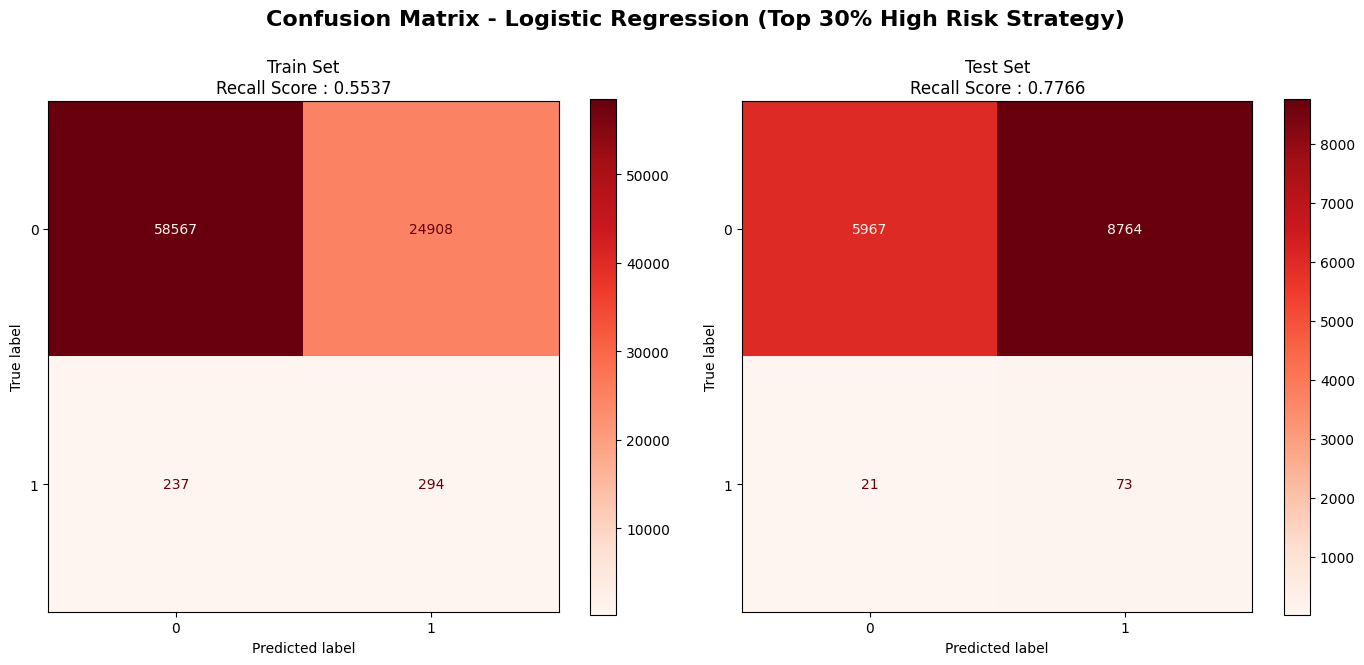

In [77]:
# threshold based on top 30%
pipe_log.fit(X_train, y_train)

y_proba_train = pipe_log.predict_proba(X_train)[:,1]
y_proba_test = pipe_log.predict_proba(X_test)[:,1]

threshold_train = np.percentile(y_proba_train, 70)
threshold_test = np.percentile(y_proba_test, 70)

y_pred_train_log = (y_proba_train >= threshold_train).astype(int)
y_pred_test_log = (y_proba_test >= threshold_test).astype(int)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14,6))

ConfusionMatrixDisplay.from_predictions(y_train,y_pred_train_log,cmap="Reds",ax=axes[0])
axes[0].set_title("Train Set\n"+ "Recall Score : "+ str(round(recall_score(y_train, y_pred_train_log),4)))

# test confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_test_log,cmap="Reds",ax=axes[1])
axes[1].set_title("Test Set\n"+ "Recall Score : "+ str(round(recall_score(y_test, y_pred_test_log),4)))

fig.suptitle("Confusion Matrix - Logistic Regression (Top 30% High Risk Strategy)",fontsize=16,weight="bold",y=1.05)

plt.tight_layout()
plt.show()

---
# Model Saving

---

In [70]:
with open('high_risk_predictor.pkl', 'wb') as file:
    pickle.dump(pipe_log, file)

---
## SHAP

---

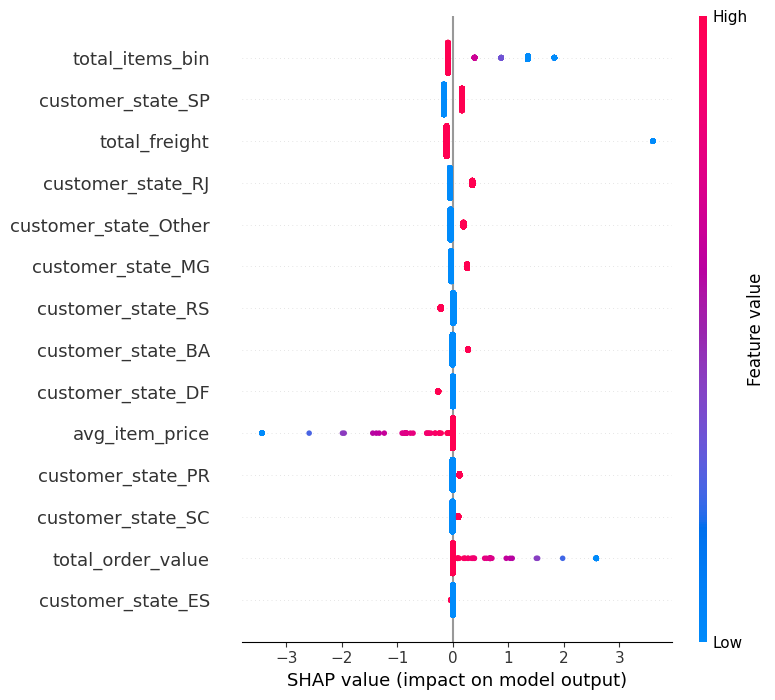

In [71]:
preprocess = pipe_log.named_steps['pipeline']
column_transformer = preprocess.named_steps['columntransformer']
log_model = pipe_log.named_steps['logisticregression']

feature_names = []

for name, trans, cols in column_transformer.transformers_:
    
    if name == 'num_nor_col':
        feature_names.extend(cols)

    elif name == 'cat_col':
        ohe = trans.named_steps['onehotencoder']
        feature_names.extend(ohe.get_feature_names_out(cols))

    elif name == 'ord_col':
        feature_names.extend(cols)

X_test_transformed = preprocess.transform(X_test)

X_test_transformed = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

explainer = shap.LinearExplainer(log_model, X_test_transformed)

shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed)

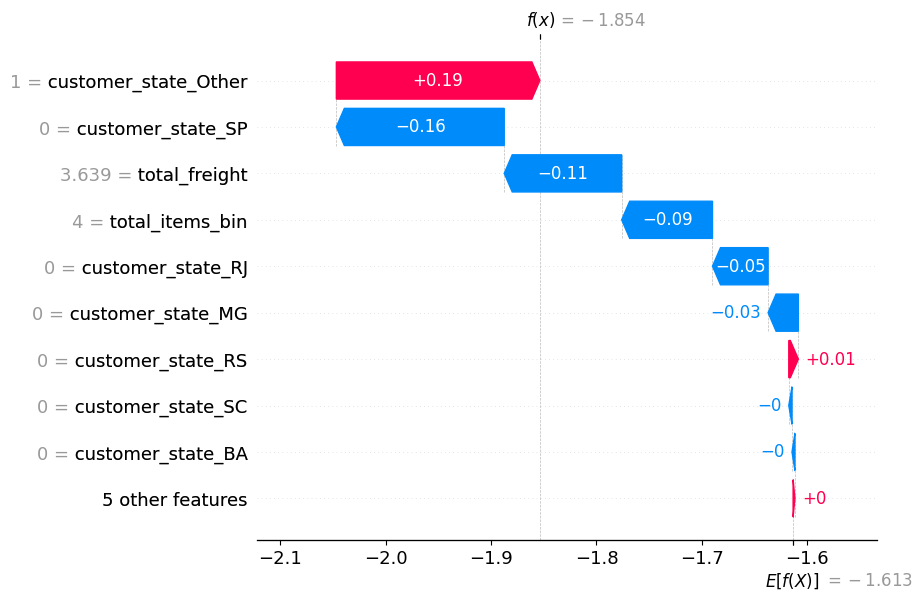

In [72]:
sample = 10

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample],
        base_values=explainer.expected_value,
        data=X_test_transformed.iloc[sample],
        feature_names=X_test_transformed.columns
    )
)

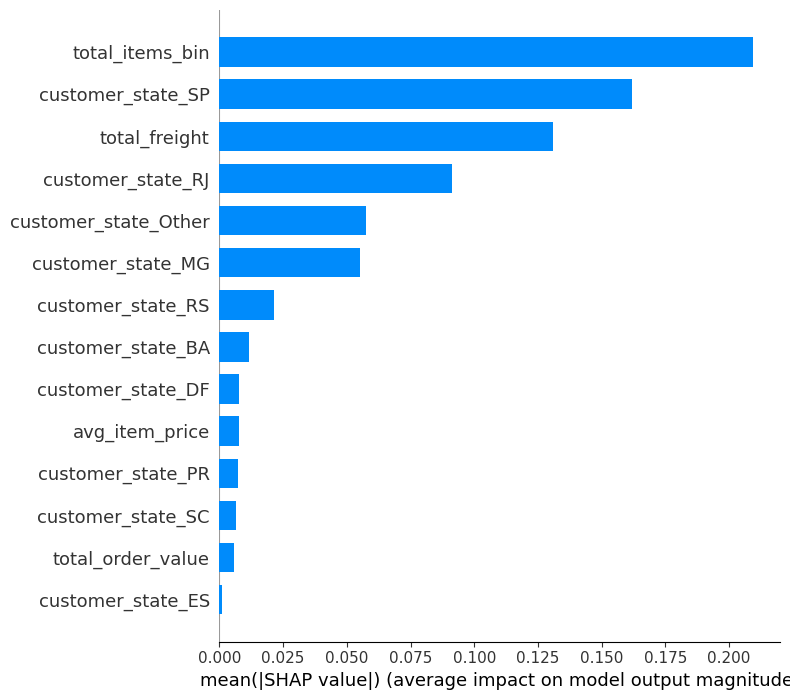

In [73]:
shap.summary_plot(shap_values, X_test_transformed, plot_type="bar")

In [74]:
shap_importance = pd.DataFrame({
    "feature": X_test_transformed.columns,
    "importance": np.abs(shap_values).mean(axis=0)
}).sort_values("importance", ascending=False)

print(shap_importance.head(10))

                 feature  importance
13       total_items_bin    0.209537
12     customer_state_SP    0.162105
1          total_freight    0.130787
9      customer_state_RJ    0.091341
7   customer_state_Other    0.057359
6      customer_state_MG    0.055180
10     customer_state_RS    0.021401
3      customer_state_BA    0.011463
4      customer_state_DF    0.007827
2         avg_item_price    0.007510
